# Spartan SAQ/SVG discovery tutorial

This notebook reproduces the spatially variable gene (SVG) analyses underlying **Figure 4** of the Spartan manuscript. The goal is to demonstrate how Spartan uses the Local Spatial Activation (LSA) graph to identify genes whose expression patterns align with activation-aware spatial structure across multiple spatial transcriptomics technologies.

The notebook covers five representative datasets:

1. **MERFISH** imaging-based spatial transcriptomics.
2. **Stereo-seq** sequencing-based spatial transcriptomics.
3. **Vizgen MERFISH** imaging-based spatial transcriptomics.
4. **DLPFC Visium** spot-based spatial transcriptomics.
5. **High-resolution Visium HD / SpatialData** developing human tissue analysis.

The workflow is intentionally organized as a figure-reproduction and reviewer-facing tutorial. It first preprocesses each dataset, constructs Spartan graphs, runs SAQ/SVG analysis using the LSA graph, ranks genes by SAQ score, and finally visualizes top-ranked marker genes spatially.

## Methodological note

Spartan SVG discovery is based on the **Spatial Activation Quotient (SAQ)**. SAQ evaluates whether a gene's expression pattern is aligned with the local activation structure encoded by the LSA graph. Unlike spatial autocorrelation tests that rely only on physical proximity, SAQ uses the activation-aware graph learned from local transcriptional deviations. This allows Spartan to identify genes that are not merely spatially clustered, but spatially aligned with biologically meaningful local activation patterns.


In [1]:
import scanpy as sc
import spartan as sp
import pandas as pd
import numpy as np
import spatialdata as sd
import matplotlib.pyplot as plt
import matplotlib as mpl 
import spatialdata_io
import spatialdata_plot
from sklearn.metrics import adjusted_rand_score
seed = 1

import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=30,
    dpi_save=30,
    facecolor="white",
    frameon=False,
)

/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## 1. Load datasets used for SVG analysis

This section loads the spatial transcriptomics datasets used to evaluate Spartan's SAQ/SVG workflow across technologies. The analysis includes imaging-based, sequencing-based, spot-based, and high-resolution spatial transcriptomics data.

The loaded objects are:

- `adata1`: MERFISH 0.19 sample.
- `adata2`: Stereo-seq E9.5E2S2 sample.
- `adata3`: Vizgen MERFISH S2R3 sample.
- `adata4`: DLPFC Visium 151673 sample.
- `sdata`: high-resolution SpatialData object for the developing human esophagus and stomach Visium HD sample.

For the Vizgen MERFISH dataset, the domain annotation is copied into `ground_truth` for consistency with the rest of the Spartan analysis workflows.


In [2]:
adata1 = sc.read_h5ad( "/PATH_TO/MERFISH/MERFISH_0.19_20250524014309.h5ad")
adata2 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E9.5_E2S2.MOSTA_20250603211807.h5ad")
adata3 = sc.read_h5ad( "/PATH_TO/merfish-vizgen/merfish_vizgen_S2R3.h5ad")
adata3.obs["ground_truth"] = adata3.obs["domain"].copy()
adata4 = sc.read_h5ad( "/PATH_TO/151673_20250620001942.h5ad")
sdata = sd.read_zarr("/PATH_TO/Visium HD sample")

version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, 

## 2. Preprocess datasets

This section applies Spartan's technology-specific preprocessing functions.

- `pre_process_imaging` is used for imaging-based single-cell spatial transcriptomics datasets such as MERFISH and Vizgen MERFISH.
- `pre_process_sequencing` is used for sequencing-based or spot/bin-based spatial transcriptomics datasets such as Stereo-seq and Visium.

The purpose of preprocessing is to prepare each dataset for graph construction by applying appropriate filtering, normalization, transformation, and PCA-compatible preparation. The preprocessing is separated by technology because imaging-based and sequencing-based spatial transcriptomics datasets have different noise structures, feature distributions, and spatial sampling characteristics.


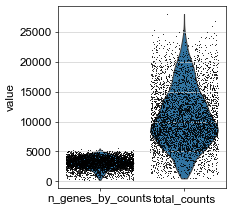

Number of zero-count cells: 0


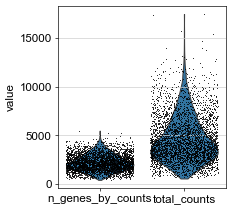

Number of zero-count cells: 0


In [3]:
a1= sp.tl.pre_process_imaging(adata1)
a2= sp.tl.pre_process_sequencing(adata2)
a3= sp.tl.pre_process_imaging(adata3)
a4= sp.tl.pre_process_sequencing(adata4)

## 3. Prepare high-resolution SpatialData table

The high-resolution Visium HD analysis is stored inside a `SpatialData` object. Before running Spartan, gene names are made unique and highly variable genes are selected for the relevant table.

This step prepares the `manual_analysis_count_area_filtered` table for Spartan graph construction and SAQ analysis. The SpatialData object is later used for shape-based spatial visualization, allowing high-resolution gene expression patterns to be rendered in tissue geometry rather than only as spot coordinates.


In [4]:
for table in sdata.tables.values():
    table.var_names_make_unique()
sc.pp.highly_variable_genes(sdata['manual_analysis_count_area_filtered'], flavor='seurat', n_top_genes=2000)
sdata['manual_analysis_count_area_filtered']    

AnnData object with n_obs × n_vars = 84732 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'region', 'clusters_res_0_5', 'clusters_res_1_3', 'clusters_res_1_5', 'clusters_res_2_0'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_res_0_5', 'clusters_res_1_3', 'clusters_res_1_5', 'clusters_res_1_5_colors', 'clusters_res_2_0', 'hvg', 'log1p', 'neighbors', 'pca', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_spatial', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'normalized_no_log', 'raw_counts'
    obsp: 'connectivities', 'distances'

## 4. Build Spartan graph components

This section constructs the Spartan graph components for each dataset.

For each AnnData object, `spartan_build_graphs` creates and stores:

- `spartan_spatial_graph`: physical spatial neighborhood graph.
- `spartan_spatial_weights`: row-normalized spatial weights.
- `spartan_lsa_graph`: Local Spatial Activation graph.
- `spartan_gene_graph`: expression-space connectivity graph.

The spatial neighborhood strategy is selected according to the dataset technology:

- Delaunay graphs are used for irregular single-cell imaging datasets such as MERFISH.
- KNN/grid-based graphs are used for grid-like or spot/bin-based technologies such as Stereo-seq, DLPFC Visium, and Visium HD.

Graph construction is performed separately from clustering because the SVG workflow uses the LSA graph directly. This makes the SVG analysis independent of a particular Leiden partition and focuses the analysis on activation-aware spatial structure.


In [5]:
ad1= sp.tl.spartan_build_graphs(adata=a1,spatial_coord="generic",spatial_neighborhood="delaunay",copy=True)
ad2= sp.tl.spartan_build_graphs(adata=a2,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad3= sp.tl.spartan_build_graphs(adata=a3,spatial_coord="generic",spatial_neighborhood="delaunay",copy=True)
ad4= sp.tl.spartan_build_graphs(adata=a4,spatial_coord="grid",spatial_neighs=6,spatial_rings=2,spatial_neighborhood="knn",copy=True)
ad5= sp.tl.spartan_build_graphs(adata=sdata['manual_analysis_count_area_filtered'],spatial_coord="grid",spatial_neighs=6,spatial_rings=2,spatial_neighborhood="knn",copy=True)

/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## 5. Extract LSA graphs for SAQ/SVG analysis

The LSA graph is the key input to Spartan's SVG workflow. Each graph encodes local transcriptional activation structure across spatial neighborhoods.

The extracted graphs are passed into `spartan_svg`, which evaluates each gene against the corresponding LSA graph. A high SAQ score indicates that a gene's expression pattern is strongly aligned with local activation structure.


In [6]:
lsa_graph1 = ad1.obsp['spartan_lsa_graph']
lsa_graph2 = ad2.obsp['spartan_lsa_graph']
lsa_graph3 = ad3.obsp['spartan_lsa_graph']
lsa_graph4 = ad4.obsp['spartan_lsa_graph']
lsa_graph5 = ad5.obsp['spartan_lsa_graph']

## 6. Run Spartan SAQ/SVG analysis on MERFISH

This cell runs Spartan's SVG workflow on the MERFISH 0.19 sample.

The function computes SAQ scores for all genes and performs permutation-based significance assessment. The `top_k_refine` parameter controls the number of top-ranked genes selected for more focused refinement after the initial screening stage.

MERFISH provides a useful imaging-based test case because single-cell spatial coordinates and local cellular neighborhoods are expected to preserve fine anatomical and cellular organization.


In [7]:
sp.tl.spartan_svg(
    adata = ad1,
    lsa_graph = lsa_graph1,
    n_permutations = 1000,
    n_cores = 8,
    top_k_refine = 155         
)

[Stage 1] 100 permutations for ALL genes
Processing 155 genes in chunks of 200 for 5803 spots/cells...
Backend: threads | dense dtype: <class 'numpy.float32'>
Completed pass1: 155/155 genes...
[Stage 2] +900 perms for top_k_refine=155 genes
[Stage 2] refinement complete.


## 7. Run Spartan SAQ/SVG analysis on Stereo-seq

This cell applies the same SAQ/SVG workflow to the Stereo-seq E9.5E2S2 sample.

Stereo-seq represents a sequencing-based spatial transcriptomics technology with different spatial sampling and expression characteristics compared with MERFISH. Applying the same SAQ framework here demonstrates that Spartan's activation-aware SVG discovery is not limited to imaging-based platforms.


In [8]:
sp.tl.spartan_svg(
    adata = ad2,
    lsa_graph = lsa_graph2,
    n_permutations = 1000,
    n_cores = 8,  
    top_k_refine = 1000         
)

[Stage 1] 100 permutations for ALL genes
Processing 19736 genes in chunks of 200 for 4321 spots/cells...
Backend: threads | dense dtype: <class 'numpy.float32'>
Completed pass1: 200/19736 genes...
Completed pass1: 2200/19736 genes...
Completed pass1: 4200/19736 genes...
Completed pass1: 6200/19736 genes...
Completed pass1: 8200/19736 genes...
Completed pass1: 10200/19736 genes...
Completed pass1: 12200/19736 genes...
Completed pass1: 14200/19736 genes...
Completed pass1: 16200/19736 genes...
Completed pass1: 18200/19736 genes...
[Stage 2] +900 perms for top_k_refine=1000 genes
[Stage 2] refinement complete.


## 8. Run Spartan SAQ/SVG analysis on Vizgen MERFISH

This cell runs SAQ/SVG analysis on the Vizgen MERFISH S2R3 sample.

This provides an additional imaging-based validation setting. The use of a second MERFISH-style dataset helps demonstrate that SAQ identifies biologically meaningful spatial genes across independent imaging-based spatial transcriptomics platforms.


In [9]:
sp.tl.spartan_svg(
    adata = ad3,
    lsa_graph = lsa_graph3,
    n_permutations = 1000,
    n_cores = 8,  
    top_k_refine = 483         
)

[Stage 1] 100 permutations for ALL genes
Processing 483 genes in chunks of 200 for 85958 spots/cells...
Backend: threads | dense dtype: <class 'numpy.float32'>
Completed pass1: 200/483 genes...
[Stage 2] +900 perms for top_k_refine=483 genes
[Stage 2] refinement complete.


## 9. Run Spartan SAQ/SVG analysis on DLPFC Visium

This cell applies the SAQ/SVG workflow to a DLPFC Visium 151673 sample.

DLPFC is a useful benchmark tissue because cortical laminar structure is well characterized. Spatially variable genes identified by Spartan can therefore be evaluated against known anatomical and cell-type-associated expression programs.


In [10]:
sp.tl.spartan_svg(
    adata = ad4,
    lsa_graph = lsa_graph4,
    n_permutations = 1000,
    n_cores = 8,  
    top_k_refine = 1000         
)

[Stage 1] 100 permutations for ALL genes
Processing 18011 genes in chunks of 200 for 3632 spots/cells...
Backend: threads | dense dtype: <class 'numpy.float32'>
Completed pass1: 200/18011 genes...
Completed pass1: 2200/18011 genes...
Completed pass1: 4200/18011 genes...
Completed pass1: 6200/18011 genes...
Completed pass1: 8200/18011 genes...
Completed pass1: 10200/18011 genes...
Completed pass1: 12200/18011 genes...
Completed pass1: 14200/18011 genes...
Completed pass1: 16200/18011 genes...
Completed pass1: 18011/18011 genes...
[Stage 2] +900 perms for top_k_refine=1000 genes
[Stage 2] refinement complete.


## 10. Run Spartan SAQ/SVG analysis on high-resolution Visium HD data

This cell applies SAQ/SVG analysis to the high-resolution developing human esophagus and stomach Visium HD sample stored in the SpatialData-derived AnnData table.

This analysis supports the biological case study in the manuscript by identifying genes aligned with high-resolution tissue architecture, including smooth muscle, epithelial, gastric, and transitional programs.


In [11]:
sp.tl.spartan_svg(
    adata = ad5,
    lsa_graph = lsa_graph5,
    n_permutations = 1000,
    n_cores = 8,  
    top_k_refine = 1000         
)

[Stage 1] 100 permutations for ALL genes
Processing 18085 genes in chunks of 200 for 84732 spots/cells...
Backend: threads | dense dtype: <class 'numpy.float32'>
Completed pass1: 200/18085 genes...
Completed pass1: 2200/18085 genes...
Completed pass1: 4200/18085 genes...
Completed pass1: 6200/18085 genes...
Completed pass1: 8200/18085 genes...
Completed pass1: 10200/18085 genes...
Completed pass1: 12200/18085 genes...
Completed pass1: 14200/18085 genes...
Completed pass1: 16200/18085 genes...
Completed pass1: 18085/18085 genes...
[Stage 2] +900 perms for top_k_refine=1000 genes
[Stage 2] refinement complete.


## 11. Inspect top-ranked MERFISH SAQ genes

The genes are ranked by `spartan_saq` in descending order. Genes with high SAQ scores show strong alignment with the LSA graph and are therefore candidates for spatially variable genes under Spartan's activation-aware definition.

This table is used to identify marker genes for downstream spatial visualization and manuscript figure generation.


In [12]:
ad1.var.sort_values("spartan_saq", ascending=False).head(50)

,mean,std,spartan_saq,spartan_saq_pval,spartan_saq_fdr,spartan_svg,spartan_saq_rank
Unnamed: 0,,,,,,,
Mbp,0.434136,1.085454,1.842687,0.000000e+00,0.000000e+00,True,1
Nnat,0.703878,0.942918,1.719159,0.000000e+00,0.000000e+00,True,2
Oxt,0.364450,0.764612,1.533765,0.000000e+00,0.000000e+00,True,3
Sln,1.103720,1.320183,1.478933,0.000000e+00,0.000000e+00,True,4
Gnrh1,0.269578,0.408717,1.229745,0.000000e+00,0.000000e+00,True,5
Tac1,0.472669,0.629938,1.196561,0.000000e+00,0.000000e+00,True,6
Vgf,0.428712,0.693723,1.163274,0.000000e+00,0.000000e+00,True,7
Scg2,0.802470,1.175620,1.138273,0.000000e+00,0.000000e+00,True,8
Cartpt,0.316238,0.517659,1.123965,0.000000e+00,0.000000e+00,True,9


## 12. Inspect top-ranked Stereo-seq SAQ genes

This table shows the highest-ranking SAQ genes for the Stereo-seq sample.

Top-ranked genes are expected to correspond to spatially organized developmental or anatomical programs. These genes are subsequently visualized to confirm whether high SAQ scores correspond to interpretable spatial expression patterns.


In [13]:
ad2.var.sort_values("spartan_saq", ascending=False).head(50)

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,mean,std,spartan_saq,spartan_saq_pval,spartan_saq_fdr,spartan_svg,spartan_saq_rank
gene_short_name,,,,,,,,,,,,,,,,,,
Hbb-bh1,4349,149.938705,5.016874,0.160698,653133,13.389538,4321,True,4.990044,5.004968,1.000000,4.709925,0.659362,2.742567,0.000000e+00,0.000000e+00,True,1
Hbb-y,4352,170.794995,5.146302,0.091827,743983,13.519775,4321,True,5.120627,4.914841,1.000000,4.888078,0.603484,2.697573,0.000000e+00,0.000000e+00,True,2
Hba-x,4339,64.399679,4.180517,0.390266,280525,12.544422,4316,True,4.169779,4.969442,1.357640,3.782343,0.725326,2.321329,0.000000e+00,0.000000e+00,True,3
Gm42418,4356,450.715106,6.113052,0.000000,1963315,14.490145,4321,True,6.003328,4.793185,1.000000,5.879880,0.489294,2.311899,0.000000e+00,0.000000e+00,True,4
Hba-a1,4281,21.562213,3.116277,1.721763,93925,11.450263,4267,True,3.089836,3.846857,4.805344,2.541677,0.960673,2.257011,0.000000e+00,0.000000e+00,True,5
Cdk8,4335,65.524105,4.197564,0.482094,285423,12.561731,4310,False,4.098377,2.983333,-0.101406,3.929555,0.635422,2.223637,0.000000e+00,0.000000e+00,True,6
Camk1d,4308,42.120523,3.763999,1.101928,183477,12.119850,4289,True,3.722511,2.971079,1.118316,3.481668,0.759082,2.216786,0.000000e+00,0.000000e+00,True,7
Ttn,1363,1.905877,1.066735,68.709826,8302,9.024372,1362,True,1.111244,3.162584,9.177060,0.433371,0.847863,2.189648,0.000000e+00,0.000000e+00,True,8
H19,4204,12.686869,2.616437,3.489440,55264,10.919895,4200,True,2.669026,2.445312,3.933744,2.312702,0.885591,2.177262,0.000000e+00,0.000000e+00,True,9


## 13. Inspect top-ranked Vizgen MERFISH SAQ genes

This table lists the top SAQ-ranked genes in the Vizgen MERFISH dataset.

The purpose is to evaluate whether SAQ recovers spatially structured genes across an independent imaging-based dataset and to select representative genes for figure panels.


In [14]:
ad3.var.sort_values("spartan_saq", ascending=False).head(50)

,n_cells,mean,std,spartan_saq,spartan_saq_pval,spartan_saq_fdr,spartan_svg,spartan_saq_rank
Slc17a7,56959,3.875303,3.016659,1.622106,0.0,0.0,True,1
Gpr151,4237,0.188847,0.893017,1.510698,0.0,0.0,True,2
Chat,1560,0.080703,0.622445,1.498606,0.0,0.0,True,3
Gfap,35840,1.844732,2.340080,1.249008,0.0,0.0,True,4
Chrm1,41582,2.339444,2.472330,1.184002,0.0,0.0,True,5
Gpr88,18025,0.846521,1.728718,1.073424,0.0,0.0,True,6
Htr5b,2831,0.118753,0.668621,1.052620,0.0,0.0,True,7
Baiap2,51186,3.040932,2.620210,1.015320,0.0,0.0,True,8
Slc17a6,24118,1.231239,2.060402,0.898791,0.0,0.0,True,9
Gabbr2,64785,3.998881,2.413646,0.893405,0.0,0.0,True,10


## 14. Inspect top-ranked DLPFC Visium SAQ genes

This table ranks genes by SAQ score in the DLPFC Visium sample.

Genes with high SAQ scores are expected to reflect spatially patterned cortical cell types or laminar structure, providing an interpretable check that Spartan's SVG workflow captures known biological organization.


In [15]:
ad4.var.sort_values("spartan_saq", ascending=False).head(50)

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,...,means,dispersions,dispersions_norm,mean,std,spartan_saq,spartan_saq_pval,spartan_saq_fdr,spartan_svg,spartan_saq_rank
MBP,ENSG00000197971,Gene Expression,GRCh38,3566,16.993130,2.889990,2.006046,61838.0,11.032290,3564,...,3.862855,4.586361,0.707107,3.131809,1.166420,2.823702,0.0,0.0,True,1
SCGB2A2,ENSG00000110484,Gene Expression,GRCh38,2540,4.933498,1.780614,30.200605,17953.0,9.795568,2537,...,2.526792,3.044132,3.150914,1.753965,1.353321,2.767421,0.0,0.0,True,2
MT-CO1,ENSG00000198804,Gene Expression,GRCh38,3639,135.168178,4.913891,0.000000,491877.0,13.105986,3632,...,5.683848,3.182507,1.154664,5.634646,0.333754,2.547789,0.0,0.0,True,3
PLP1,ENSG00000123560,Gene Expression,GRCh38,3283,9.711734,2.371340,9.782907,35341.0,10.472827,3283,...,3.286749,4.196050,2.760198,2.369140,1.349242,2.398674,0.0,0.0,True,4
MOBP,ENSG00000168314,Gene Expression,GRCh38,1643,1.241825,0.807290,54.850234,4519.0,8.416267,1643,...,1.484833,2.502085,6.163146,0.816618,1.047113,2.209794,0.0,0.0,True,5
GFAP,ENSG00000131095,Gene Expression,GRCh38,2993,3.920308,1.593371,17.752130,14266.0,9.565704,2992,...,2.505649,3.183826,3.430370,1.771548,1.216272,2.182437,0.0,0.0,True,6
MT-CO3,ENSG00000198938,Gene Expression,GRCh38,3639,107.948612,4.690876,0.000000,392825.0,12.881122,3632,...,5.468406,2.749234,-0.569399,5.430879,0.287527,2.112450,0.0,0.0,True,7
TF,ENSG00000091513,Gene Expression,GRCh38,1995,1.766145,1.017454,45.177246,6427.0,8.768418,1995,...,1.733538,2.670090,7.563676,1.022353,1.117944,1.981242,0.0,0.0,True,8
SCGB1D2,ENSG00000124935,Gene Expression,GRCh38,1889,1.397362,0.874369,48.090135,5085.0,8.534247,1889,...,1.464734,2.083245,4.194588,0.931815,1.000582,1.957483,0.0,0.0,True,9
CNP,ENSG00000173786,Gene Expression,GRCh38,2728,3.232207,1.442724,25.034350,11762.0,9.372714,2728,...,2.237864,3.010072,5.866203,1.519111,1.179102,1.911282,0.0,0.0,True,10


## 15. Inspect top-ranked high-resolution Visium HD SAQ genes

This table lists top SAQ-ranked genes from the high-resolution developing human esophagus/stomach dataset.

These genes are used to identify spatially organized biological programs in the Visium HD case study, including smooth muscle, gastric epithelial, stromal, and regional tissue programs.


In [16]:
ad5.var.sort_values("spartan_saq", ascending=False).head(70)

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std,spartan_saq,spartan_saq_pval,spartan_saq_fdr,spartan_svg,spartan_saq_rank
ACTG2,ENSG00000163017,Gene Expression,GRCh38,19447,0.651324,0.501577,77.048813,55188.0,10.918519,True,0.483640,1.357977,1.073279,0.268540,0.549991,1.284105,0.0,0.0,True,1
SPINK1,ENSG00000164266,Gene Expression,GRCh38,13750,0.467899,0.383832,83.772365,39646.0,10.587771,True,0.258615,1.070912,2.357476,0.150045,0.385178,1.216534,0.0,0.0,True,2
TAGLN,ENSG00000149591,Gene Expression,GRCh38,22704,0.677064,0.517045,73.204928,57369.0,10.957277,False,0.500665,1.190897,0.624821,0.296609,0.550035,1.174660,0.0,0.0,True,3
DES,ENSG00000175084,Gene Expression,GRCh38,17080,0.488411,0.397709,79.842326,41384.0,10.630674,True,0.384099,1.181124,1.254139,0.218519,0.482493,1.144305,0.0,0.0,True,4
COL3A1,ENSG00000168542,Gene Expression,GRCh38,56203,2.080536,1.125104,33.669688,176288.0,12.079880,True,1.132938,1.143663,1.000000,0.848212,0.743708,1.086402,0.0,0.0,True,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNC,ENSG00000041982,Gene Expression,GRCh38,8370,0.120781,0.114026,90.121796,10234.0,9.233568,False,0.095043,0.263645,-0.370028,0.065031,0.213959,0.296500,0.0,0.0,True,66
TACSTD2,ENSG00000184292,Gene Expression,GRCh38,4626,0.068180,0.065956,94.540433,5777.0,8.661813,False,0.045579,0.339554,0.544668,0.031038,0.145825,0.296289,0.0,0.0,True,67
COL5A1,ENSG00000130635,Gene Expression,GRCh38,25826,0.422839,0.352654,69.520370,35828.0,10.486513,False,0.336256,0.421635,-0.679058,0.237567,0.401632,0.292887,0.0,0.0,True,68
FN1,ENSG00000115414,Gene Expression,GRCh38,11363,0.168343,0.155586,86.589482,14264.0,9.565564,False,0.140952,0.372301,0.138622,0.095114,0.264142,0.292170,0.0,0.0,True,69


## 16. Spatial visualization of top MERFISH SAQ genes

This section visualizes selected top-ranked MERFISH genes on tissue coordinates.

The selected genes represent spatially structured programs identified by Spartan's SAQ ranking. Spatial visualization is essential because SVG discovery should not only produce high statistical scores, but also recover interpretable tissue-localized expression patterns.


/tmp/ipykernel_603109/522954923.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad1,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=10.0,legend_loc=None)


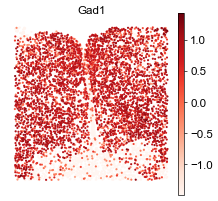

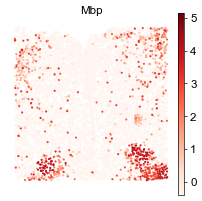

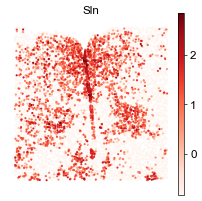

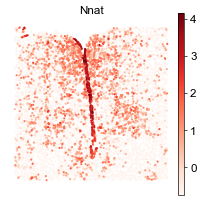

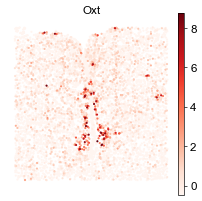

<Figure size 120x120 with 0 Axes>

In [17]:
genes = ["Gad1","Mbp", "Sln", "Nnat", "Oxt"]
for i, gene in enumerate(genes):
  sc.pl.spatial(ad1,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=10.0,legend_loc=None)


plt.tight_layout()
plt.show()

## 17. Spatial visualization of top Stereo-seq SAQ genes

This section visualizes representative top-ranked Stereo-seq genes.

Genes such as cardiac or muscle-associated markers are expected to show strong localized spatial structure in the developing embryo sample. These plots provide visual validation that SAQ captures anatomically organized expression patterns in sequencing-based spatial transcriptomics data.


/tmp/ipykernel_603109/2513667788.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad2,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=0.5,legend_loc=None)


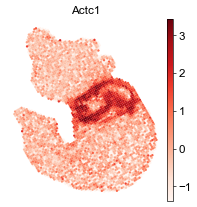

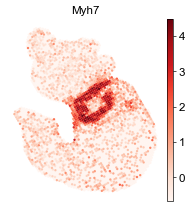

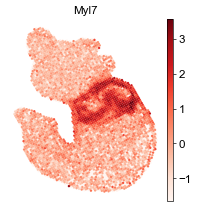

<Figure size 120x120 with 0 Axes>

In [18]:
genes = ["Actc1","Myh7", "Myl7"]
for i, gene in enumerate(genes):
  sc.pl.spatial(ad2,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=0.5,legend_loc=None)


plt.tight_layout()
plt.show()

## 18. Spatial visualization of top Vizgen MERFISH SAQ genes

This section visualizes selected top SAQ-ranked genes in the Vizgen MERFISH dataset.

The goal is to demonstrate that Spartan identifies spatially coherent genes across an independent single-cell imaging dataset. The displayed markers are used as representative examples for Figure 4 panels.


/tmp/ipykernel_603109/242198036.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad3,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=30.0,legend_loc=None)


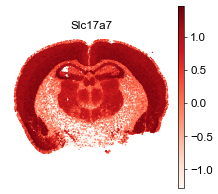

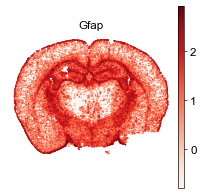

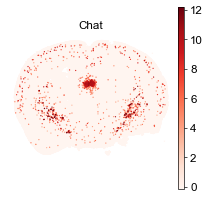

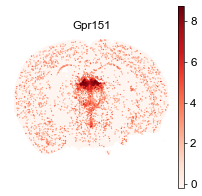

<Figure size 120x120 with 0 Axes>

In [19]:
genes = ["Slc17a7","Gfap", "Chat", "Gpr151"]
for i, gene in enumerate(genes):
  sc.pl.spatial(ad3,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=30.0,legend_loc=None)


plt.tight_layout()
plt.show()

## 19. Spatial visualization of top DLPFC Visium SAQ genes

This section visualizes selected top-ranked genes in the DLPFC Visium dataset.

The markers are expected to correspond to spatially organized cortical or glial programs. This analysis demonstrates that SAQ can identify meaningful spatial genes in spot-based spatial transcriptomics data, not only single-cell imaging data.


/tmp/ipykernel_603109/1974682598.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad4,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=50.0,legend_loc=None)


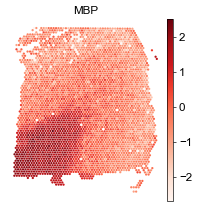

/tmp/ipykernel_603109/1974682598.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad4,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=50.0,legend_loc=None)


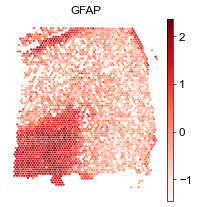

/tmp/ipykernel_603109/1974682598.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad4,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=50.0,legend_loc=None)


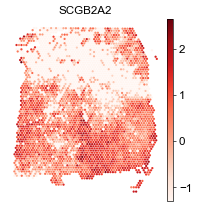

<Figure size 120x120 with 0 Axes>

In [20]:
genes = ["MBP","GFAP", "SCGB2A2"]
for i, gene in enumerate(genes):
  sc.pl.spatial(ad4,img_key=None, color=gene,color_map="Reds",wspace=0.4,size=2.5, spot_size=50.0,legend_loc=None)


plt.tight_layout()
plt.show()

## 20. SpatialData visualization of high-resolution Visium HD SAQ genes

This section visualizes selected high-ranking SAQ genes using SpatialData's shape-rendering workflow.

Unlike standard spot plots, shape-based rendering preserves high-resolution tissue geometry. This is particularly important for Visium HD-style analyses, where the biological interpretation depends on fine anatomical structures such as epithelial layers, smooth muscle regions, gastric compartments, and transitional zones.

The selected genes support the high-resolution biological interpretation shown in Supplementary Figure 26 by demonstrating that Spartan's SAQ workflow identifies genes with clear and interpretable spatial localization.


/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `manual_analysis_count_area_filtered` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `analysis_geometry` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `manual_analysis_count_area_filtered` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `analysis_geometry` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), sel

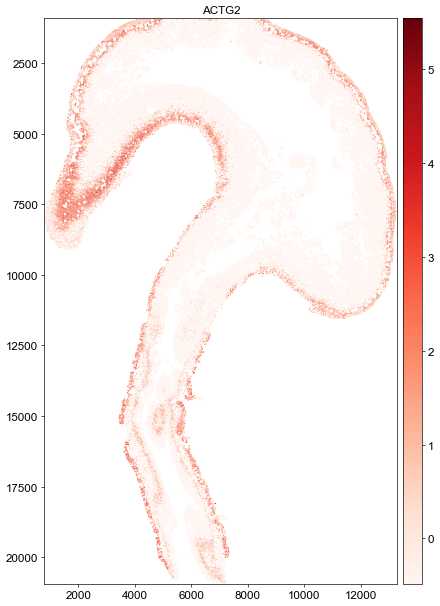

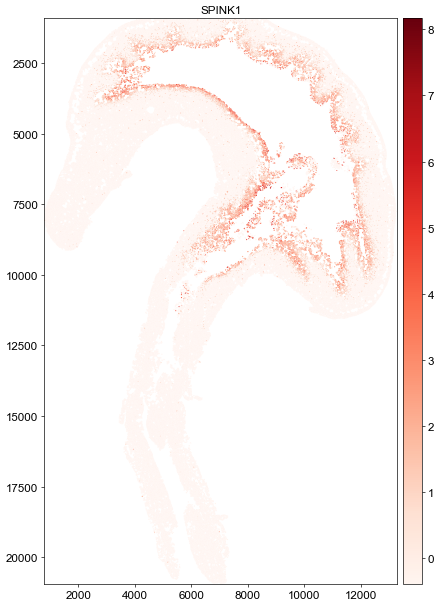

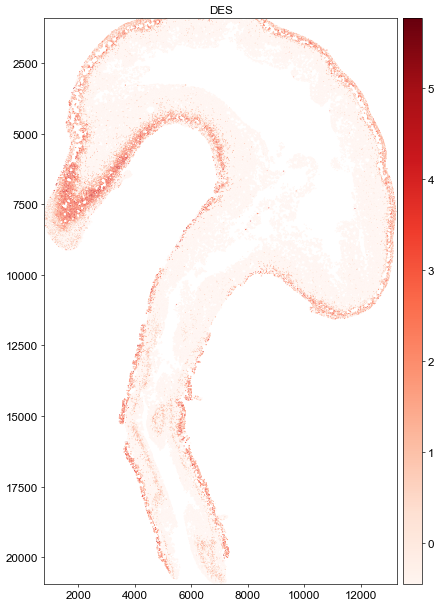

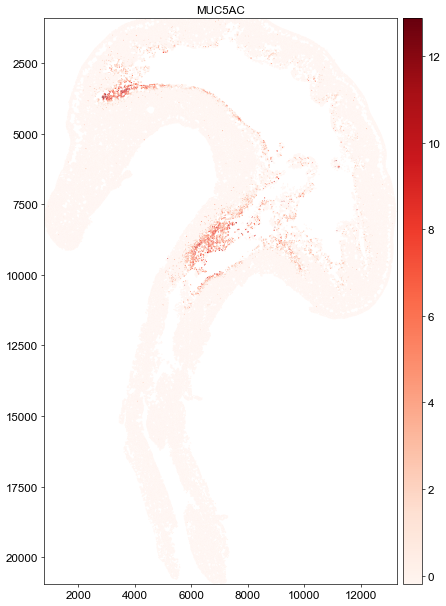

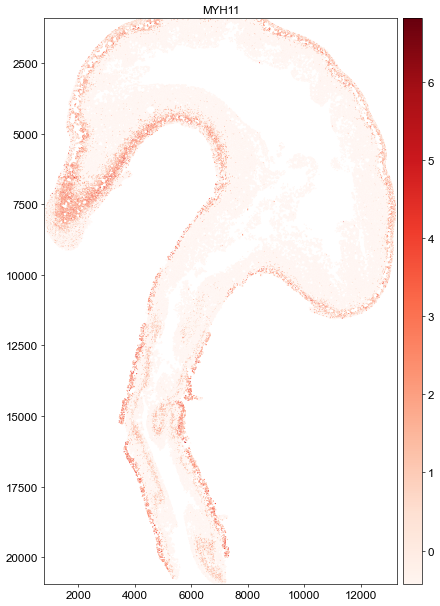

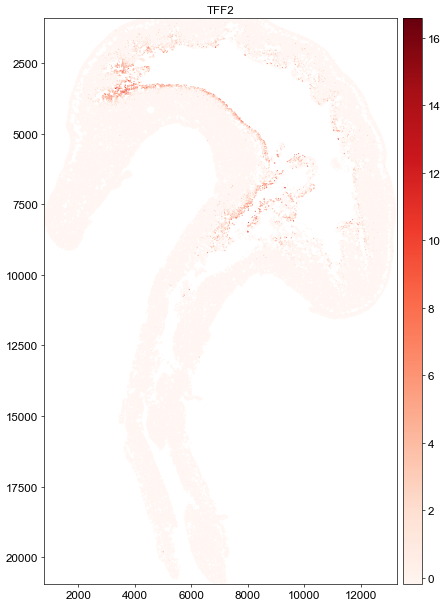

In [21]:
sdata["manual_analysis_count_area_filtered"] = ad5.copy()
plt.rcParams['axes.grid'] = False 
genes = ["ACTG2", "SPINK1", "DES", "MUC5AC", "MYH11", "TFF2"]
for i, gene in enumerate(genes):
  sdata.pl.render_shapes(
    "analysis_geometry",
    cmap="Reds",
    color=gene,
    method="matplotlib",
    table_name="manual_analysis_count_area_filtered"
).pl.show(
    coordinate_systems="RJ4_D1_Andy_Esophagus",
    figsize=(10, 10),
    title=gene,     # or "KRT13"
    frameon=False
)

plt.show()

## Summary

This notebook reproduces the Spartan SAQ/SVG analyses underlying Figure 4 and Supplementary Figure 26 of the manuscript. Across imaging-based, sequencing-based, spot-based, and high-resolution spatial transcriptomics datasets, Spartan identifies genes whose expression patterns align with Local Spatial Activation structure.

The analysis demonstrates that SAQ-ranked genes produce interpretable spatial patterns across multiple technologies, supporting the use of Spartan not only for spatial domain identification but also for activation-aware spatially variable gene discovery.
